In [ ]:
# Install all required libraries — every notebook is self-contained
!pip install fastapi uvicorn scikit-fem nest-asyncio requests pyngrok meshio -q

import nest_asyncio
nest_asyncio.apply()

print("✅ Libraries installed and nest-asyncio applied")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.2/166.2 kB 12.3 MB/s eta 0:00:00
✅ Libraries installed and nest-asyncio applied


In [ ]:
import os
import json
import time
import uuid
import logging
import threading
import requests
import asyncio
import uvicorn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import Optional, List
from uvicorn import Config, Server
from google.colab import drive

# scikit-fem imports
from skfem import (
    MeshTri,
    MeshQuad,
    Basis,
    ElementTriP1,
    ElementVector,
    FacetBasis,
    asm,
    solve,
    condense
)
from skfem.models.elasticity import linear_elasticity
from skfem.assembly import LinearForm

# Mount Drive
drive.mount('/content/drive')

# Define paths
DRIVE_PATH = '/content/drive/MyDrive/MCL_Orchestrator/'

PATHS = {
    'notebooks' : f'{DRIVE_PATH}notebooks/',
    'services'  : f'{DRIVE_PATH}services/',
    'results'   : f'{DRIVE_PATH}results/',
    'logs'      : f'{DRIVE_PATH}logs/',
    'docs'      : f'{DRIVE_PATH}docs/'
}

# Confirm folders
print("\nConfirming Drive folder structure:")
print("=" * 45)
all_exist = True
for name, path in PATHS.items():
    exists = os.path.exists(path)
    status = "✅ Found" if exists else "❌ Missing"
    print(f"  {name:<12} : {status}")
    if not exists:
        all_exist = False

print("=" * 45)
if all_exist:
    print("✅ All folders confirmed — ready to build pipeline")
else:
    print("❌ Some folders missing — check Drive before continuing")

Mounted at /content/drive

Confirming Drive folder structure:
  notebooks    : ✅ Found
  services     : ✅ Found
  results      : ✅ Found
  logs         : ✅ Found
  docs         : ✅ Found
✅ All folders confirmed — ready to build pipeline


In [ ]:
# ── Logger ────────────────────────────────────────────────────────
log_file_path = f'{DRIVE_PATH}logs/pipeline.log'

if not os.path.exists(log_file_path):
    with open(log_file_path, 'w') as f:
        f.write(f"MCL Orchestrator — Pipeline Log\n")
        f.write(f"Created : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("=" * 60 + "\n")

logger = logging.getLogger('MCL_Orchestrator')
logger.setLevel(logging.INFO)

if not logger.handlers:
    file_handler = logging.FileHandler(log_file_path)
    file_handler.setLevel(logging.INFO)
    file_handler.setFormatter(logging.Formatter(
        '%(asctime)s | %(levelname)s | %(message)s',
        datefmt='%Y-%m-%d %H:%M:%S'
    ))
    console_handler = logging.StreamHandler()
    console_handler.setLevel(logging.INFO)
    console_handler.setFormatter(logging.Formatter(
        '%(asctime)s | %(levelname)s | %(message)s',
        datefmt='%Y-%m-%d %H:%M:%S'
    ))
    logger.addHandler(file_handler)
    logger.addHandler(console_handler)

def log_event(stage, status, detail=''):
    message = f"{stage:<30} | {status:<10} | {detail}"
    if status == 'ERROR':
        logger.error(message)
    elif status == 'WARNING':
        logger.warning(message)
    else:
        logger.info(message)

# ── Pipeline State ────────────────────────────────────────────────
state_file_path = f'{DRIVE_PATH}logs/pipeline_state.json'

pipeline_state = {
    'job_id'      : None,
    'started_at'  : None,
    'stages'      : {
        'A_parameter_generation': 'pending',
        'B_fem_simulation'      : 'pending',
        'C_postprocessing'      : 'pending'
    },
    'errors'      : [],
    'completed_at': None
}

def update_state(stage, status, error=None):
    pipeline_state['stages'][stage] = status
    if error:
        pipeline_state['errors'].append({
            'stage'    : stage,
            'error'    : str(error),
            'timestamp': datetime.now().isoformat()
        })
        log_event(stage, 'ERROR', str(error))
    else:
        log_event(stage, status, f"Stage updated to {status}")
    with open(state_file_path, 'w') as f:
        json.dump(pipeline_state, f, indent=4)

def reset_pipeline_state():
    pipeline_state['job_id']       = None
    pipeline_state['started_at']   = None
    pipeline_state['completed_at'] = None
    pipeline_state['errors']       = []
    pipeline_state['stages'] = {
        'A_parameter_generation': 'pending',
        'B_fem_simulation'      : 'pending',
        'C_postprocessing'      : 'pending'
    }
    with open(state_file_path, 'w') as f:
        json.dump(pipeline_state, f, indent=4)
    log_event('pipeline', 'INFO', 'Pipeline state reset to pending')

# ── Retry Handler ─────────────────────────────────────────────────
def post_with_retry(url, data, max_retries=3, backoff=2):
    log_event('retry_handler', 'INFO',
              f"POST to {url} | max_retries={max_retries}")
    for attempt in range(max_retries):
        try:
            response = requests.post(url, json=data, timeout=60)
            response.raise_for_status()
            log_event('retry_handler', 'SUCCESS',
                      f"POST succeeded on attempt {attempt + 1}")
            return response.json()
        except requests.exceptions.ConnectionError:
            if attempt < max_retries - 1:
                wait = backoff ** attempt
                print(f"  ⚠️  Service unreachable — retrying in {wait}s "
                      f"(attempt {attempt + 1}/{max_retries})")
                log_event('retry_handler', 'WARNING',
                          f"Connection failed — retrying in {wait}s")
                time.sleep(wait)
            else:
                log_event('retry_handler', 'ERROR',
                          f"Unreachable after {max_retries} attempts")
                raise RuntimeError(
                    f"❌ Service at {url} unreachable after "
                    f"{max_retries} attempts"
                )
        except requests.exceptions.Timeout:
            log_event('retry_handler', 'ERROR', f"Timeout at {url}")
            raise RuntimeError(f"❌ Service at {url} timed out")
        except requests.exceptions.HTTPError as e:
            log_event('retry_handler', 'ERROR', f"HTTP error: {e}")
            raise RuntimeError(f"❌ HTTP error: {e}")

print("✅ Shared utilities reinitialised:")
print("   Logger              : ✅ handler guard active")
print("   State tracker       : ✅ ready")
print("   State reset function: ✅ ready")
print("   Retry handler       : ✅ ready")
log_event('04_full_pipeline', 'INFO',
          'Shared utilities initialised in Notebook 5')

✅ Shared utilities reinitialised:
   Logger              : ✅ handler guard active
   State tracker       : ✅ ready
   State reset function: ✅ ready
   Retry handler       : ✅ ready


2026-06-02 07:44:39 | INFO | 04_full_pipeline               | INFO       | Shared utilities initialised in Notebook 5
INFO:MCL_Orchestrator:04_full_pipeline               | INFO       | Shared utilities initialised in Notebook 5


In [ ]:
# ══════════════════════════════════════════════════════════════════
# SERVICE A — Parameter Generator
# ══════════════════════════════════════════════════════════════════

class ParameterRequest(BaseModel):
    E_fiber_GPa           : float = 380.0
    E_matrix_GPa          : float = 90.0
    fiber_volume_fraction : float = 0.45
    nu                    : float = 0.20
    applied_stress_MPa    : float = 300.0
    length_mm             : float = 100.0
    width_mm              : float = 20.0

def compute_effective_modulus(E_fiber_GPa, E_matrix_GPa, Vf):
    return round(Vf * E_fiber_GPa + (1 - Vf) * E_matrix_GPa, 3)

def validate_parameters(p: ParameterRequest):
    errors = []
    if not (100 <= p.E_fiber_GPa <= 500):
        errors.append(f"E_fiber_GPa={p.E_fiber_GPa} out of range")
    if not (50 <= p.E_matrix_GPa <= 200):
        errors.append(f"E_matrix_GPa={p.E_matrix_GPa} out of range")
    if not (0.3 <= p.fiber_volume_fraction <= 0.7):
        errors.append(f"fiber_volume_fraction={p.fiber_volume_fraction} out of range")
    if not (0.1 <= p.nu <= 0.45):
        errors.append(f"nu={p.nu} out of range")
    if p.applied_stress_MPa <= 0:
        errors.append(f"applied_stress_MPa must be positive")
    if p.applied_stress_MPa > 1500:
        errors.append(f"applied_stress_MPa exceeds 1500 MPa")
    if p.length_mm <= 0 or p.width_mm <= 0:
        errors.append("Coupon dimensions must be positive")
    if p.length_mm <= p.width_mm:
        errors.append("length_mm must exceed width_mm")
    if errors:
        log_event('Service A — validation', 'ERROR',
                  f"{len(errors)} error(s)")
        raise HTTPException(status_code=422, detail=errors)
    log_event('Service A — validation', 'SUCCESS',
              'All parameters valid')

app_a = FastAPI(title="Service A — Parameter Generator")

@app_a.post('/generate')
def generate_parameters(p: ParameterRequest = None):
    if p is None:
        p = ParameterRequest()
    job_id = str(uuid.uuid4())[:8].upper()
    pipeline_state['job_id']     = job_id
    pipeline_state['started_at'] = datetime.now().isoformat()
    pipeline_state['errors']     = []
    update_state('A_parameter_generation', 'running')
    log_event('Service A', 'INFO', f"Job started | job_id={job_id}")
    validate_parameters(p)
    E_eff = compute_effective_modulus(
        p.E_fiber_GPa, p.E_matrix_GPa, p.fiber_volume_fraction
    )
    payload = {
        'job_id'               : job_id,
        'E_GPa'                : E_eff,
        'nu'                   : p.nu,
        'applied_stress'       : p.applied_stress_MPa,
        'length_mm'            : p.length_mm,
        'width_mm'             : p.width_mm,
        'fiber_volume_fraction': p.fiber_volume_fraction,
        'E_fiber_GPa'          : p.E_fiber_GPa,
        'E_matrix_GPa'         : p.E_matrix_GPa,
        'timestamp'            : datetime.now().isoformat()
    }
    log_event('Service A', 'SUCCESS',
              f"Payload assembled | E_eff={E_eff} GPa | job={job_id}")
    update_state('A_parameter_generation', 'complete')
    try:
        log_event('Service A', 'INFO',
                  f"Triggering Service B | job={job_id}")
        service_b_response = post_with_retry(
            'http://localhost:8002/simulate', payload
        )
        return {
            'status'     : 'pipeline_triggered',
            'job_id'     : job_id,
            'parameters' : payload,
            'service_b'  : service_b_response
        }
    except RuntimeError as e:
        update_state('A_parameter_generation', 'error', str(e))
        return {
            'status'    : 'service_b_unreachable',
            'job_id'    : job_id,
            'parameters': payload,
            'error'     : str(e)
        }

@app_a.get('/health')
def health_a():
    return {
        'service'  : 'A — Parameter Generator',
        'status'   : 'online',
        'port'     : 8001,
        'timestamp': datetime.now().isoformat()
    }

@app_a.get('/state')
def state_a():
    return {
        'pipeline_state': pipeline_state,
        'timestamp'     : datetime.now().isoformat()
    }

print("✅ Service A defined")

# ══════════════════════════════════════════════════════════════════
# SERVICE B — FEM Simulation
# ══════════════════════════════════════════════════════════════════

class SimulationInput(BaseModel):
    job_id                : str
    E_GPa                 : float
    nu                    : float
    applied_stress        : float
    length_mm             : float
    width_mm              : float
    fiber_volume_fraction : float
    E_fiber_GPa           : float
    E_matrix_GPa          : float
    timestamp             : str

def validate_sim_inputs(p: SimulationInput):
    errors = []
    if not (10 <= p.E_GPa <= 500):
        errors.append(f"E_GPa={p.E_GPa} out of range")
    if not (0.1 <= p.nu <= 0.45):
        errors.append(f"nu={p.nu} out of range")
    if p.applied_stress <= 0:
        errors.append("applied_stress must be positive")
    if p.applied_stress > 1500:
        errors.append("applied_stress exceeds 1500 MPa")
    if p.length_mm <= p.width_mm:
        errors.append("length_mm must exceed width_mm")
    if errors:
        log_event('Service B — validation', 'ERROR',
                  f"{len(errors)} error(s)")
        raise HTTPException(status_code=422, detail=errors)
    log_event('Service B — validation', 'SUCCESS',
              'All inputs valid')

def run_fem_simulation(E_GPa, nu, applied_stress,
                       length, width,
                       n_length=20, n_width=5):
    E   = E_GPa * 1e3
    mesh = MeshTri.init_tensor(
        np.linspace(0, length, n_length + 1),
        np.linspace(0, width,  n_width  + 1)
    )
    element = ElementVector(ElementTriP1())
    basis   = Basis(mesh, element)
    lam = (E * nu) / ((1 + nu) * (1 - 2 * nu))
    mu  = E / (2 * (1 + nu))
    K   = asm(linear_elasticity(lam, mu), basis)
    f   = np.zeros(K.shape[0])
    all_boundary    = mesh.boundary_facets()
    facet_midpoints = mesh.p[:, mesh.facets].mean(axis=1)
    right_facets    = all_boundary[
        facet_midpoints[0, all_boundary] > length - 1e-10
    ]
    rbasis = FacetBasis(mesh, element, facets=right_facets)

    @LinearForm
    def traction(v, w):
        return applied_stress * v.value[0]

    f += traction.assemble(rbasis)
    left_facets = all_boundary[
        facet_midpoints[0, all_boundary] < 1e-10
    ]
    left_dofs = basis.get_dofs(left_facets)
    u   = solve(*condense(K, f, D=left_dofs))
    u_x = u[basis.nodal_dofs[0]]
    u_y = u[basis.nodal_dofs[1]]
    max_axial_disp   = float(np.max(np.abs(u_x)))
    max_lateral_disp = float(np.max(np.abs(u_y)))
    axial_strain     = max_axial_disp / length
    eff_modulus_GPa  = (applied_stress / (axial_strain + 1e-12)) / 1e3
    return {
        'max_axial_displacement_mm'  : round(max_axial_disp,   6),
        'max_lateral_displacement_mm': round(max_lateral_disp, 6),
        'axial_strain'               : round(axial_strain,     8),
        'effective_modulus_GPa'      : round(eff_modulus_GPa,  4),
        'applied_stress_MPa'         : round(applied_stress,   2),
        'lame_lambda'                : round(lam,              4),
        'lame_mu'                    : round(mu,               4),
        'n_nodes'                    : mesh.p.shape[1],
        'n_elements'                 : mesh.t.shape[1],
        'status'                     : 'complete'
    }

def validate_sim_output(result, params: SimulationInput):
    issues   = []
    warnings = []
    if result['max_axial_displacement_mm'] >= params.length_mm:
        issues.append("Axial displacement exceeds coupon length")
    if result['effective_modulus_GPa'] <= 0:
        issues.append("Non-physical negative modulus")
    if result['axial_strain'] > 0.1:
        issues.append("Axial strain exceeds 10%")
    modulus_error_pct = abs(
        result['effective_modulus_GPa'] - params.E_GPa
    ) / params.E_GPa * 100
    if modulus_error_pct > 15:
        warnings.append(
            f"Modulus deviates {modulus_error_pct:.1f}% from input"
        )
    if issues:
        result['status'] = 'failed'
        result['issues'] = issues
    elif warnings:
        result['status']   = 'warned'
        result['warnings'] = warnings
    else:
        result['status']            = 'complete'
        result['modulus_error_pct'] = round(modulus_error_pct, 2)
    return result

app_b = FastAPI(title="Service B — FEM Simulation")

@app_b.post('/simulate')
def simulate(params: SimulationInput):
    update_state('B_fem_simulation', 'running')
    log_event('Service B', 'INFO',
              f"Simulation started | job={params.job_id}")
    validate_sim_inputs(params)
    try:
        result = run_fem_simulation(
            E_GPa          = params.E_GPa,
            nu             = params.nu,
            applied_stress = params.applied_stress,
            length         = params.length_mm,
            width          = params.width_mm
        )
        result['job_id']               = params.job_id
        result['fiber_volume_fraction']= params.fiber_volume_fraction
        result['E_input_GPa']          = params.E_GPa
        result['E_fiber_GPa']          = params.E_fiber_GPa
        result['E_matrix_GPa']         = params.E_matrix_GPa
        result['nu_input']             = params.nu
        result['length_mm']            = params.length_mm
        result['width_mm']             = params.width_mm
        result = validate_sim_output(result, params)
        if result['status'] in ['complete', 'warned']:
            update_state('B_fem_simulation', result['status'])
            log_event('Service B', 'SUCCESS',
                      f"FEM complete | job={params.job_id} | "
                      f"E_eff={result['effective_modulus_GPa']} GPa")
            try:
                svc_c = post_with_retry(
                    'http://localhost:8003/postprocess', result
                )
                result['service_c'] = svc_c
            except RuntimeError as e:
                result['service_c'] = {
                    'status': 'unreachable', 'error': str(e)
                }
        else:
            update_state('B_fem_simulation', 'failed',
                         result.get('issues', ''))
        return result
    except Exception as e:
        update_state('B_fem_simulation', 'error', str(e))
        raise HTTPException(status_code=500,
                           detail=f"FEM failed: {str(e)}")

@app_b.get('/health')
def health_b():
    return {
        'service'  : 'B — FEM Simulation',
        'status'   : 'online',
        'port'     : 8002,
        'timestamp': datetime.now().isoformat()
    }

@app_b.get('/state')
def state_b():
    return {
        'pipeline_state': pipeline_state,
        'timestamp'     : datetime.now().isoformat()
    }

print("✅ Service B defined")

# ══════════════════════════════════════════════════════════════════
# SERVICE C — Postprocessor
# ══════════════════════════════════════════════════════════════════

class FEMResult(BaseModel):
    job_id                      : str
    max_axial_displacement_mm   : float
    max_lateral_displacement_mm : float
    axial_strain                : float
    effective_modulus_GPa       : float
    applied_stress_MPa          : float
    fiber_volume_fraction       : float
    E_input_GPa                 : float
    E_fiber_GPa                 : float
    E_matrix_GPa                : float
    nu_input                    : float
    length_mm                   : float
    width_mm                    : float
    n_nodes                     : int
    n_elements                  : int
    status                      : str
    modulus_error_pct           : Optional[float] = None
    issues                      : Optional[List[str]] = []
    warnings                    : Optional[List[str]] = []
    lame_lambda                 : Optional[float] = None
    lame_mu                     : Optional[float] = None

def check_stress_strain_consistency(result: FEMResult):
    sigma_computed = result.effective_modulus_GPa * 1e3 * result.axial_strain
    sigma_applied  = result.applied_stress_MPa
    error_pct      = abs(sigma_computed - sigma_applied) / sigma_applied * 100
    return {
        'check'    : 'Stress-Strain Consistency',
        'error_pct': round(error_pct, 2),
        'tolerance': 10,
        'passed'   : error_pct < 10
    }

def check_poisson_effect(result: FEMResult):
    lateral_strain = result.max_lateral_displacement_mm / result.width_mm
    nu_computed    = lateral_strain / (result.axial_strain + 1e-12)
    error_pct      = abs(nu_computed - result.nu_input) / result.nu_input * 100
    return {
        'check'    : 'Poisson Effect',
        'error_pct': round(error_pct, 2),
        'tolerance': 20,
        'passed'   : error_pct < 20
    }

def check_modulus_consistency(result: FEMResult):
    error_pct = abs(
        result.effective_modulus_GPa - result.E_input_GPa
    ) / result.E_input_GPa * 100
    return {
        'check'    : 'Modulus Consistency',
        'error_pct': round(error_pct, 2),
        'tolerance': 15,
        'passed'   : error_pct < 15
    }

def run_all_checks(result: FEMResult):
    checks = [
        check_stress_strain_consistency(result),
        check_poisson_effect(result),
        check_modulus_consistency(result)
    ]
    return {
        'checks'    : checks,
        'all_passed': all(c['passed'] for c in checks),
        'timestamp' : datetime.now().isoformat()
    }

def generate_results_plot(result: FEMResult, analysis: dict, job_id: str):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
        f'FEM Results — Job {job_id} — Status: {result.status.upper()}',
        fontsize=13, fontweight='bold', y=1.02
    )
    # Panel 1 — Deformation schematic
    ax1 = axes[0]
    L   = result.length_mm
    W   = result.width_mm
    ds  = result.max_axial_displacement_mm * 100
    lat = result.max_lateral_displacement_mm * 100
    ax1.add_patch(plt.Polygon(
        [[0,0],[L,0],[L,W],[0,W]],
        fill=False, edgecolor='steelblue',
        linewidth=2, linestyle='--', label='Original'
    ))
    ax1.add_patch(plt.Polygon(
        [[0,0],[L+ds,0],[L+ds,W-lat],[0,W]],
        fill=True, facecolor='steelblue',
        alpha=0.3, edgecolor='steelblue',
        linewidth=2, label='Deformed (x100)'
    ))
    for y in np.linspace(0, W, 5):
        ax1.plot([-6, 0], [y, y], color='coral', linewidth=1.2)
    ax1.plot([0, 0], [0, W], color='coral', linewidth=2.5)
    ax1.annotate('', xy=(L+ds+10, W/2), xytext=(L+ds+2, W/2),
                arrowprops=dict(arrowstyle='->', color='mediumseagreen', lw=2))
    ax1.text(L+ds+12, W/2,
             f"σ={result.applied_stress_MPa:.0f}MPa",
             color='mediumseagreen', fontsize=8, va='center')
    ax1.set_xlim(-15, L+ds+30)
    ax1.set_ylim(-8, W+15)
    ax1.set_xlabel('Length (mm)', fontsize=10)
    ax1.set_ylabel('Width (mm)', fontsize=10)
    ax1.set_title('Deformation Schematic\n(x100 scale)',
                  fontsize=10, fontweight='bold')
    ax1.legend(fontsize=8)
    ax1.set_aspect('equal')
    # Panel 2 — Metrics bar chart
    ax2 = axes[1]
    metrics = {
        'E_voigt\n(GPa)' : result.E_input_GPa,
        'E_fem\n(GPa)'   : result.effective_modulus_GPa,
        'σ\n(MPa)'       : result.applied_stress_MPa,
        'ε x10³\n(-)'    : result.axial_strain * 1000
    }
    bars = ax2.bar(metrics.keys(), metrics.values(),
                   color=['steelblue','cornflowerblue','coral','mediumseagreen'],
                   edgecolor='white', width=0.5)
    for bar, val in zip(bars, metrics.values()):
        ax2.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{val:.3f}', ha='center', fontsize=8)
    check_lines = '\n'.join([
        f"[{'PASS' if c['passed'] else 'FAIL'}] "
        f"{c['check']}: {c['error_pct']}%"
        for c in analysis['checks']
    ])
    ax2.text(0.5, -0.28, check_lines,
             transform=ax2.transAxes, fontsize=7.5,
             ha='center', va='top', family='monospace',
             bbox=dict(boxstyle='round', facecolor='#eef3fb', alpha=0.8))
    ax2.set_title('Key Results', fontsize=10, fontweight='bold')
    ax2.set_ylabel('Value')
    ax2.set_ylim(0, max(metrics.values()) * 1.15)
    # Panel 3 — Parameter table
    ax3 = axes[2]
    ax3.axis('off')
    table_data = [
        ['Parameter',          'Value',       'Unit'],
        ['Fiber vol. frac.',   f"{result.fiber_volume_fraction:.2f}", '-'],
        ['E_fiber',            f"{result.E_fiber_GPa:.1f}",  'GPa'],
        ['E_matrix',           f"{result.E_matrix_GPa:.1f}", 'GPa'],
        ['E_voigt',            f"{result.E_input_GPa:.1f}",  'GPa'],
        ["Poisson's ratio",    f"{result.nu_input:.2f}",     '-'],
        ['Applied stress',     f"{result.applied_stress_MPa:.1f}", 'MPa'],
        ['Max axial disp.',    f"{result.max_axial_displacement_mm:.6f}", 'mm'],
        ['Max lateral disp.',  f"{result.max_lateral_displacement_mm:.6f}", 'mm'],
        ['Axial strain',       f"{result.axial_strain:.6f}", '-'],
        ['E_fem',              f"{result.effective_modulus_GPa:.3f}", 'GPa'],
        ['Modulus error',      f"{result.modulus_error_pct:.1f}" if result.modulus_error_pct else 'N/A', '%'],
        ['Status',             result.status.upper(), '-']
    ]
    table = ax3.table(
        cellText  = [r for r in table_data[1:]],
        colLabels = table_data[0],
        cellLoc   = 'center', loc='center',
        bbox      = [0, 0, 1, 1]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    for (r, c), cell in table.get_celld().items():
        if r == 0:
            cell.set_facecolor('#2c3e7a')
            cell.set_text_props(color='white', fontweight='bold')
        elif r % 2 == 0:
            cell.set_facecolor('#eef3fb')
        if r == len(table_data) - 1:
            color = '#d4edda' if result.status == 'complete' else \
                    '#fff3cd' if result.status == 'warned' else '#f8d7da'
            cell.set_facecolor(color)
    ax3.set_title('Simulation Parameters', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plot_path = f'{DRIVE_PATH}results/fem_results_{job_id}.png'
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.close()
    log_event('Service C — plot', 'SUCCESS',
              f"Plot saved | job={job_id}")
    return plot_path

def save_metrics_json(result: FEMResult, analysis: dict, plot_path: str):
    metrics = {
        'job_id'   : result.job_id,
        'timestamp': datetime.now().isoformat(),
        'status'   : result.status,
        'inputs'   : {
            'E_fiber_GPa'          : result.E_fiber_GPa,
            'E_matrix_GPa'         : result.E_matrix_GPa,
            'E_voigt_GPa'          : result.E_input_GPa,
            'fiber_volume_fraction': result.fiber_volume_fraction,
            'nu'                   : result.nu_input,
            'applied_stress_MPa'   : result.applied_stress_MPa,
            'length_mm'            : result.length_mm,
            'width_mm'             : result.width_mm
        },
        'fem_outputs': {
            'max_axial_displacement_mm'  : result.max_axial_displacement_mm,
            'max_lateral_displacement_mm': result.max_lateral_displacement_mm,
            'axial_strain'               : result.axial_strain,
            'effective_modulus_GPa'      : result.effective_modulus_GPa,
            'modulus_error_pct'          : result.modulus_error_pct,
            'n_nodes'                    : result.n_nodes,
            'n_elements'                 : result.n_elements
        },
        'analysis_checks': {
            c['check']: {
                'passed'   : c['passed'],
                'error_pct': c['error_pct'],
                'tolerance': c['tolerance']
            }
            for c in analysis['checks']
        },
        'overall_passed': analysis['all_passed'],
        'issues'        : result.issues   if result.issues   else [],
        'warnings'      : result.warnings if result.warnings else [],
        'files'         : {
            'plot' : plot_path,
            'log'  : log_file_path,
            'state': state_file_path
        }
    }
    json_path = f'{DRIVE_PATH}results/metrics_{result.job_id}.json'
    with open(json_path, 'w') as f:
        json.dump(metrics, f, indent=4)
    log_event('Service C — metrics', 'SUCCESS',
              f"Metrics JSON saved | job={result.job_id}")
    return json_path, metrics

app_c = FastAPI(title="Service C — Postprocessor")

@app_c.post('/postprocess')
def postprocess(result: FEMResult):
    update_state('C_postprocessing', 'running')
    log_event('Service C', 'INFO',
              f"Postprocessing | job={result.job_id} | "
              f"status={result.status}")
    try:
        if result.status == 'failed':
            failure_record = {
                'job_id'   : result.job_id,
                'timestamp': datetime.now().isoformat(),
                'status'   : 'failed',
                'issues'   : result.issues,
                'inputs'   : {
                    'E_input_GPa'          : result.E_input_GPa,
                    'fiber_volume_fraction': result.fiber_volume_fraction,
                    'applied_stress_MPa'   : result.applied_stress_MPa
                }
            }
            failure_path = (
                f'{DRIVE_PATH}results/failed_{result.job_id}.json'
            )
            with open(failure_path, 'w') as f:
                json.dump(failure_record, f, indent=4)
            update_state('C_postprocessing', 'failed',
                         f"Failed FEM result: {result.issues}")
            return {
                'status'  : 'failed',
                'job_id'  : result.job_id,
                'issues'  : result.issues,
                'saved_to': failure_path
            }
        analysis  = run_all_checks(result)
        plot_path = generate_results_plot(result, analysis, result.job_id)
        json_path, metrics = save_metrics_json(result, analysis, plot_path)
        pipeline_state['completed_at'] = datetime.now().isoformat()
        final_status = result.status
        update_state('C_postprocessing', final_status)
        log_event('Service C', 'SUCCESS',
                  f"Pipeline complete | job={result.job_id} | "
                  f"status={final_status}")
        final_state_path = (
            f'{DRIVE_PATH}logs/pipeline_state_{result.job_id}.json'
        )
        with open(final_state_path, 'w') as f:
            json.dump(pipeline_state, f, indent=4)
        return {
            'status'         : final_status,
            'job_id'         : result.job_id,
            'analysis_passed': analysis['all_passed'],
            'plot_path'      : plot_path,
            'metrics_path'   : json_path,
            'state_path'     : final_state_path
        }
    except Exception as e:
        update_state('C_postprocessing', 'error', str(e))
        raise HTTPException(status_code=500,
                           detail=f"Postprocessing failed: {str(e)}")

@app_c.get('/health')
def health_c():
    return {
        'service'  : 'C — Postprocessor',
        'status'   : 'online',
        'port'     : 8003,
        'timestamp': datetime.now().isoformat()
    }

@app_c.get('/state')
def state_c():
    return {
        'pipeline_state': pipeline_state,
        'timestamp'     : datetime.now().isoformat()
    }

@app_c.get('/results')
def list_results():
    results_path = f'{DRIVE_PATH}results/'
    files  = os.listdir(results_path)
    plots  = sorted([f for f in files if f.endswith('.png')])
    jsons  = sorted([f for f in files if f.endswith('.json')])
    return {
        'results_folder': results_path,
        'total_files'   : len(files),
        'plots'         : plots,
        'json_files'    : jsons
    }

print("✅ Service C defined")
print("\n" + "=" * 50)
print("  All 3 services defined and ready to start")
print("=" * 50)

✅ Service A defined
✅ Service B defined
✅ Service C defined

  All 3 services defined and ready to start


In [ ]:
# ── Start Service A ───────────────────────────────────────────────
async def serve_a():
    config = Config(
        app=app_a, host='0.0.0.0', port=8001, log_level='warning'
    )
    server = Server(config)
    await server.serve()

def run_service_a():
    loop = asyncio.new_event_loop()
    asyncio.set_event_loop(loop)
    loop.run_until_complete(serve_a())

# ── Start Service B ───────────────────────────────────────────────
async def serve_b():
    config = Config(
        app=app_b, host='0.0.0.0', port=8002, log_level='warning'
    )
    server = Server(config)
    await server.serve()

def run_service_b():
    loop = asyncio.new_event_loop()
    asyncio.set_event_loop(loop)
    loop.run_until_complete(serve_b())

# ── Start Service C ───────────────────────────────────────────────
async def serve_c():
    config = Config(
        app=app_c, host='0.0.0.0', port=8003, log_level='warning'
    )
    server = Server(config)
    await server.serve()

def run_service_c():
    loop = asyncio.new_event_loop()
    asyncio.set_event_loop(loop)
    loop.run_until_complete(serve_c())

# ── Launch all three in background threads ────────────────────────
print("Starting all services...")
print("=" * 45)

thread_a = threading.Thread(target=run_service_a, daemon=True)
thread_b = threading.Thread(target=run_service_b, daemon=True)
thread_c = threading.Thread(target=run_service_c, daemon=True)

thread_a.start()
print("  ⏳ Service A starting on port 8001...")
time.sleep(2)

thread_b.start()
print("  ⏳ Service B starting on port 8002...")
time.sleep(2)

thread_c.start()
print("  ⏳ Service C starting on port 8003...")
time.sleep(2)

print("=" * 45)
print("  All threads launched — running health checks...")

Starting all services...
  ⏳ Service A starting on port 8001...
  ⏳ Service B starting on port 8002...
  ⏳ Service C starting on port 8003...
  All threads launched — running health checks...


In [ ]:
services = {
    'A — Parameter Generator' : 'http://localhost:8001/health',
    'B — FEM Simulation'      : 'http://localhost:8002/health',
    'C — Postprocessor'       : 'http://localhost:8003/health'
}

print("Pipeline Health Check")
print("=" * 58)
print(f"  {'Service':<28} {'Port':>6} {'Status':>10} {'Timestamp'}")
print("  " + "-" * 55)

all_healthy = True
for name, url in services.items():
    try:
        r      = requests.get(url, timeout=5)
        health = r.json()
        print(f"  ✅ {name:<26} {health['port']:>6} "
              f"{'online':>10}   {health['timestamp']}")
    except Exception as e:
        print(f"  ❌ {name:<26} {'—':>6} {'offline':>10}   {str(e)}")
        all_healthy = False

print("  " + "-" * 55)

if all_healthy:
    print("\n  ✅ All services online — pipeline ready to run")
    log_event('04_full_pipeline', 'INFO',
              'All 3 services online — pipeline ready')
else:
    print("\n  ❌ Some services offline — check Cell 5 before continuing")
    log_event('04_full_pipeline', 'ERROR',
              'One or more services failed health check')

print("=" * 58)
print(f"\n  Event-driven chain:")
print(f"    POST /generate  → Service A validates + computes E_eff")
print(f"    → triggers POST /simulate  → Service B runs FEM")
print(f"    → triggers POST /postprocess → Service C saves results")
print(f"\n  Single trigger cell fires the entire A → B → C chain")

Pipeline Health Check
  Service                        Port     Status Timestamp
  -------------------------------------------------------
  ✅ A — Parameter Generator      8001     online   2026-06-02T07:46:26.204137
  ✅ B — FEM Simulation           8002     online   2026-06-02T07:46:26.220075
  ✅ C — Postprocessor            8003     online   2026-06-02T07:46:26.233162
  -------------------------------------------------------

  ✅ All services online — pipeline ready to run


2026-06-02 07:46:26 | INFO | 04_full_pipeline               | INFO       | All 3 services online — pipeline ready
INFO:MCL_Orchestrator:04_full_pipeline               | INFO       | All 3 services online — pipeline ready



  Event-driven chain:
    POST /generate  → Service A validates + computes E_eff
    → triggers POST /simulate  → Service B runs FEM
    → triggers POST /postprocess → Service C saves results

  Single trigger cell fires the entire A → B → C chain


In [ ]:
# Reset pipeline state for a clean run
reset_pipeline_state()
print("Pipeline state reset — starting happy path run")
print("=" * 55)

# Standard SiC/SiC parameters
parameters = {
    'E_fiber_GPa'          : 380.0,
    'E_matrix_GPa'         : 90.0,
    'fiber_volume_fraction': 0.45,
    'nu'                   : 0.20,
    'applied_stress_MPa'   : 300.0,
    'length_mm'            : 100.0,
    'width_mm'             : 20.0
}

print(f"\n  Input parameters:")
for k, v in parameters.items():
    print(f"    {k:<25} : {v}")

print(f"\n  Triggering Service A...")
print("  " + "-" * 50)

# Fire the pipeline
response = requests.post(
    'http://localhost:8001/generate',
    json    = parameters,
    timeout = 120
)

result = response.json()

# ── Top level response ────────────────────────────────────────────
print(f"\n  HTTP Status      : {response.status_code}")
print(f"  Pipeline status  : {result.get('status')}")
print(f"  Job ID           : {result.get('job_id')}")

# ── Service A results ─────────────────────────────────────────────
params = result.get('parameters', {})
print(f"\n  Service A — Parameter Generation:")
print(f"    E_eff (Voigt)  : {params.get('E_GPa')} GPa")
print(f"    Vf             : {params.get('fiber_volume_fraction')}")
print(f"    Applied stress : {params.get('applied_stress')} MPa")

# ── Service B results ─────────────────────────────────────────────
svc_b = result.get('service_b', {})
print(f"\n  Service B — FEM Simulation:")
print(f"    Status         : {svc_b.get('status')}")
print(f"    Max axial disp : {svc_b.get('max_axial_displacement_mm')} mm")
print(f"    Axial strain   : {svc_b.get('axial_strain')}")
print(f"    E_fem computed : {svc_b.get('effective_modulus_GPa')} GPa")
print(f"    Modulus error  : {svc_b.get('modulus_error_pct')}%")

# ── Service C results ─────────────────────────────────────────────
svc_c = svc_b.get('service_c', {})
print(f"\n  Service C — Postprocessing:")
print(f"    Status         : {svc_c.get('status')}")
print(f"    Analysis passed: {svc_c.get('analysis_passed')}")
print(f"    Plot saved     : {svc_c.get('plot_path')}")
print(f"    Metrics saved  : {svc_c.get('metrics_path')}")
print(f"    State saved    : {svc_c.get('state_path')}")

# ── File existence check ──────────────────────────────────────────
print(f"\n  File existence check:")
for label, key in [
    ('Plot',    'plot_path'),
    ('Metrics', 'metrics_path'),
    ('State',   'state_path')
]:
    path   = svc_c.get(key, '')
    exists = os.path.exists(path)
    print(f"    {label:<10} : {'✅ Found' if exists else '❌ Missing'}")

# ── Final pipeline state ──────────────────────────────────────────
state = requests.get('http://localhost:8001/state', timeout=5).json()
stages = state['pipeline_state']['stages']

print(f"\n  Final pipeline state:")
print(f"  " + "-" * 45)
for stage, status in stages.items():
    icon = "✅" if status == 'complete' else \
           "⚠️ " if status == 'warned'  else \
           "❌" if status in ['error', 'failed'] else "⏳"
    print(f"    {icon} {stage:<35} : {status}")
print(f"  " + "-" * 45)

errors = state['pipeline_state']['errors']
print(f"  Errors logged : {len(errors)}")
print(f"  Job ID        : {state['pipeline_state']['job_id']}")
print(f"  Started at    : {state['pipeline_state']['started_at']}")
print(f"  Completed at  : {state['pipeline_state']['completed_at']}")

print("=" * 55)
if all(s == 'complete' for s in stages.values()):
    print("  ✅ Happy path confirmed — full A → B → C chain complete")
else:
    print("  ⚠️  Pipeline did not fully complete — check logs")
print("=" * 55)

2026-06-02 07:47:46 | INFO | pipeline                       | INFO       | Pipeline state reset to pending
INFO:MCL_Orchestrator:pipeline                       | INFO       | Pipeline state reset to pending
2026-06-02 07:47:46 | INFO | A_parameter_generation         | running    | Stage updated to running
INFO:MCL_Orchestrator:A_parameter_generation         | running    | Stage updated to running
2026-06-02 07:47:46 | INFO | Service A                      | INFO       | Job started | job_id=8CA0DEEA
INFO:MCL_Orchestrator:Service A                      | INFO       | Job started | job_id=8CA0DEEA
2026-06-02 07:47:46 | INFO | Service A — validation         | SUCCESS    | All parameters valid
INFO:MCL_Orchestrator:Service A — validation         | SUCCESS    | All parameters valid
2026-06-02 07:47:46 | INFO | Service A                      | SUCCESS    | Payload assembled | E_eff=220.5 GPa | job=8CA0DEEA
INFO:MCL_Orchestrator:Service A                      | SUCCESS    | Payload assembled 

Pipeline state reset — starting happy path run

  Input parameters:
    E_fiber_GPa               : 380.0
    E_matrix_GPa              : 90.0
    fiber_volume_fraction     : 0.45
    nu                        : 0.2
    applied_stress_MPa        : 300.0
    length_mm                 : 100.0
    width_mm                  : 20.0

  Triggering Service A...
  --------------------------------------------------


2026-06-02 07:47:46 | INFO | B_fem_simulation               | complete   | Stage updated to complete
INFO:MCL_Orchestrator:B_fem_simulation               | complete   | Stage updated to complete
2026-06-02 07:47:46 | INFO | Service B                      | SUCCESS    | FEM complete | job=8CA0DEEA | E_eff=229.7681 GPa
INFO:MCL_Orchestrator:Service B                      | SUCCESS    | FEM complete | job=8CA0DEEA | E_eff=229.7681 GPa
2026-06-02 07:47:46 | INFO | retry_handler                  | INFO       | POST to http://localhost:8003/postprocess | max_retries=3
INFO:MCL_Orchestrator:retry_handler                  | INFO       | POST to http://localhost:8003/postprocess | max_retries=3
2026-06-02 07:47:46 | INFO | C_postprocessing               | running    | Stage updated to running
INFO:MCL_Orchestrator:C_postprocessing               | running    | Stage updated to running
2026-06-02 07:47:46 | INFO | Service C                      | INFO       | Postprocessing | job=8CA0DEEA | statu


  HTTP Status      : 200
  Pipeline status  : pipeline_triggered
  Job ID           : 8CA0DEEA

  Service A — Parameter Generation:
    E_eff (Voigt)  : 220.5 GPa
    Vf             : 0.45
    Applied stress : 300.0 MPa

  Service B — FEM Simulation:
    Status         : complete
    Max axial disp : 0.130566 mm
    Axial strain   : 0.00130566
    E_fem computed : 229.7681 GPa
    Modulus error  : 4.2%

  Service C — Postprocessing:
    Status         : complete
    Analysis passed: True
    Plot saved     : /content/drive/MyDrive/MCL_Orchestrator/results/fem_results_8CA0DEEA.png
    Metrics saved  : /content/drive/MyDrive/MCL_Orchestrator/results/metrics_8CA0DEEA.json
    State saved    : /content/drive/MyDrive/MCL_Orchestrator/logs/pipeline_state_8CA0DEEA.json

  File existence check:
    Plot       : ✅ Found
    Metrics    : ✅ Found
    State      : ✅ Found

  Final pipeline state:
  ---------------------------------------------
    ✅ A_parameter_generation              : complete


In [ ]:
# Reset pipeline state for a clean run
reset_pipeline_state()
print("Pipeline state reset — starting error handling run")
print("=" * 55)

# Deliberately invalid parameters
invalid_parameters = {
    'E_fiber_GPa'          : 999.0,    # too high
    'E_matrix_GPa'         : 90.0,
    'fiber_volume_fraction': 0.95,     # out of range
    'nu'                   : 0.20,
    'applied_stress_MPa'   : -100.0,   # negative
    'length_mm'            : 10.0,     # shorter than width
    'width_mm'             : 20.0
}

print(f"\n  Invalid parameters being sent:")
for k, v in invalid_parameters.items():
    print(f"    {k:<25} : {v}")

print(f"\n  Triggering Service A with invalid parameters...")
print("  " + "-" * 50)

response = requests.post(
    'http://localhost:8001/generate',
    json    = invalid_parameters,
    timeout = 30
)

result = response.json()

# ── Response ──────────────────────────────────────────────────────
print(f"\n  HTTP Status : {response.status_code}")

if response.status_code == 422:
    print(f"  ✅ Pipeline correctly halted at Service A")
    print(f"\n  Validation errors returned:")
    errors = result.get('detail', [])
    for i, error in enumerate(errors, 1):
        print(f"    {i}. {error}")
else:
    print(f"  ❌ Unexpected status: {response.status_code}")

# ── Confirm Services B and C were never triggered ─────────────────
print(f"\n  Confirming Services B and C were not triggered:")
state = requests.get('http://localhost:8001/state', timeout=5).json()
stages = state['pipeline_state']['stages']
print(f"  " + "-" * 45)
for stage, status in stages.items():
    icon = "✅" if status == 'complete' else \
           "⏳" if status == 'pending'  else \
           "❌" if status in ['error', 'failed'] else "🔄"
    print(f"    {icon} {stage:<35} : {status}")
print(f"  " + "-" * 45)

b_untriggered = stages['B_fem_simulation']   == 'pending'
c_untriggered = stages['C_postprocessing']   == 'pending'

print(f"\n  Service B triggered : {'❌ No — correct' if b_untriggered else '⚠️  Yes — unexpected'}")
print(f"  Service C triggered : {'❌ No — correct' if c_untriggered else '⚠️  Yes — unexpected'}")

# ── Confirm all services still online ─────────────────────────────
print(f"\n  Confirming all services still online after bad request:")
print(f"  " + "-" * 45)
all_online = True
for name, url in [
    ('Service A', 'http://localhost:8001/health'),
    ('Service B', 'http://localhost:8002/health'),
    ('Service C', 'http://localhost:8003/health')
]:
    try:
        r = requests.get(url, timeout=5).json()
        print(f"    ✅ {name} : {r['status']}")
    except Exception as e:
        print(f"    ❌ {name} : offline — {e}")
        all_online = False
print(f"  " + "-" * 45)

print("=" * 55)
if response.status_code == 422 and b_untriggered and c_untriggered and all_online:
    print("  ✅ Error handling confirmed:")
    print("     — Pipeline halted cleanly at Service A")
    print("     — Services B and C never triggered")
    print("     — All services remain online after bad request")
else:
    print("  ⚠️  Unexpected behaviour — check output above")
print("=" * 55)

2026-06-02 07:50:09 | INFO | pipeline                       | INFO       | Pipeline state reset to pending
INFO:MCL_Orchestrator:pipeline                       | INFO       | Pipeline state reset to pending
2026-06-02 07:50:09 | INFO | A_parameter_generation         | running    | Stage updated to running
INFO:MCL_Orchestrator:A_parameter_generation         | running    | Stage updated to running
2026-06-02 07:50:09 | INFO | Service A                      | INFO       | Job started | job_id=A8155AED
INFO:MCL_Orchestrator:Service A                      | INFO       | Job started | job_id=A8155AED
2026-06-02 07:50:09 | ERROR | Service A — validation         | ERROR      | 4 error(s)
ERROR:MCL_Orchestrator:Service A — validation         | ERROR      | 4 error(s)


Pipeline state reset — starting error handling run

  Invalid parameters being sent:
    E_fiber_GPa               : 999.0
    E_matrix_GPa              : 90.0
    fiber_volume_fraction     : 0.95
    nu                        : 0.2
    applied_stress_MPa        : -100.0
    length_mm                 : 10.0
    width_mm                  : 20.0

  Triggering Service A with invalid parameters...
  --------------------------------------------------

  HTTP Status : 422
  ✅ Pipeline correctly halted at Service A

  Validation errors returned:
    1. E_fiber_GPa=999.0 out of range
    2. fiber_volume_fraction=0.95 out of range
    3. applied_stress_MPa must be positive
    4. length_mm must exceed width_mm

  Confirming Services B and C were not triggered:
  ---------------------------------------------
    🔄 A_parameter_generation              : running
    ⏳ B_fem_simulation                    : pending
    ⏳ C_postprocessing                    : pending
  --------------------------------

In [ ]:
# Parametric sweep over 5 fiber volume fractions
sweep_values = [0.30, 0.40, 0.45, 0.55, 0.65]
sweep_results = []

print("Run 3 — Parametric Sweep")
print("=" * 60)
print(f"  Sweeping fiber volume fraction: {sweep_values}")
print(f"  Fixed parameters:")
print(f"    E_fiber        : 380.0 GPa")
print(f"    E_matrix       : 90.0  GPa")
print(f"    nu             : 0.20")
print(f"    Applied stress : 300.0 MPa")
print(f"    Coupon         : 100mm x 20mm")
print("=" * 60)

for i, vf in enumerate(sweep_values, 1):

    # Reset state for each run
    reset_pipeline_state()

    # Compute expected E_eff for reference
    E_eff_expected = vf * 380.0 + (1 - vf) * 90.0

    print(f"\n  Run {i}/5 — Vf = {vf} | E_eff expected = {E_eff_expected:.1f} GPa")
    print(f"  " + "-" * 50)

    parameters = {
        'E_fiber_GPa'          : 380.0,
        'E_matrix_GPa'         : 90.0,
        'fiber_volume_fraction': vf,
        'nu'                   : 0.20,
        'applied_stress_MPa'   : 300.0,
        'length_mm'            : 100.0,
        'width_mm'             : 20.0
    }

    try:
        response = requests.post(
            'http://localhost:8001/generate',
            json    = parameters,
            timeout = 120
        )

        result  = response.json()
        svc_b   = result.get('service_b', {})
        svc_c   = svc_b.get('service_c', {})
        job_id  = result.get('job_id', 'UNKNOWN')

        # Extract key results
        E_voigt  = result.get('parameters', {}).get('E_GPa', None)
        E_fem    = svc_b.get('effective_modulus_GPa', None)
        disp     = svc_b.get('max_axial_displacement_mm', None)
        strain   = svc_b.get('axial_strain', None)
        mod_err  = svc_b.get('modulus_error_pct', None)
        status_b = svc_b.get('status', 'unknown')
        status_c = svc_c.get('status', 'unknown')

        # Store for plotting
        sweep_results.append({
            'job_id'               : job_id,
            'vf'                   : vf,
            'E_voigt_GPa'          : E_voigt,
            'E_fem_GPa'            : E_fem,
            'displacement_mm'      : disp,
            'axial_strain'         : strain,
            'modulus_error_pct'    : mod_err,
            'status_b'             : status_b,
            'status_c'             : status_c
        })

        print(f"    Job ID         : {job_id}")
        print(f"    E_voigt        : {E_voigt} GPa")
        print(f"    E_fem          : {E_fem} GPa")
        print(f"    Displacement   : {disp} mm")
        print(f"    Modulus error  : {mod_err}%")
        print(f"    Service B      : {status_b}")
        print(f"    Service C      : {status_c}")

        icon = "✅" if status_b == 'complete' and \
                       status_c == 'complete' else "⚠️ "
        print(f"    Result         : {icon} {'Complete' if icon == '✅' else 'Check above'}")

    except Exception as e:
        print(f"    ❌ Run failed: {e}")
        sweep_results.append({
            'job_id'           : 'FAILED',
            'vf'               : vf,
            'E_voigt_GPa'      : None,
            'E_fem_GPa'        : None,
            'displacement_mm'  : None,
            'axial_strain'     : None,
            'modulus_error_pct': None,
            'status_b'         : 'failed',
            'status_c'         : 'failed'
        })

# ── Summary table ─────────────────────────────────────────────────
print(f"\n{'=' * 60}")
print(f"  Parametric Sweep Summary")
print(f"{'=' * 60}")
print(f"  {'Vf':>5} {'Job ID':>10} {'E_voigt':>10} "
      f"{'E_fem':>10} {'Disp(mm)':>10} {'Err%':>7} {'Status':>10}")
print(f"  " + "-" * 58)

for r in sweep_results:
    print(f"  {r['vf']:>5.2f} "
          f"{r['job_id']:>10} "
          f"{str(r['E_voigt_GPa']):>10} "
          f"{str(r['E_fem_GPa']):>10} "
          f"{str(r['displacement_mm']):>10} "
          f"{str(r['modulus_error_pct']):>7} "
          f"{r['status_b']:>10}")

print(f"  " + "-" * 58)

# Confirm all result files saved to Drive
results_response = requests.get(
    'http://localhost:8003/results',
    timeout=5
).json()

print(f"\n  Files saved to Drive:")
print(f"    Total files : {results_response['total_files']}")
print(f"    Plots       : {len(results_response['plots'])}")
print(f"    JSON files  : {len(results_response['json_files'])}")

successful = sum(
    1 for r in sweep_results if r['status_b'] == 'complete'
)
print(f"\n  Successful runs : {successful}/{len(sweep_values)}")
print(f"{'=' * 60}")
if successful == len(sweep_values):
    print(f"  ✅ Parametric sweep complete — all runs successful")
else:
    print(f"  ⚠️  Some runs failed — check output above")
print(f"{'=' * 60}")

log_event('04_full_pipeline', 'INFO',
          f"Parametric sweep complete | "
          f"{successful}/{len(sweep_values)} runs successful")

2026-06-02 07:51:59 | INFO | pipeline                       | INFO       | Pipeline state reset to pending
INFO:MCL_Orchestrator:pipeline                       | INFO       | Pipeline state reset to pending
2026-06-02 07:51:59 | INFO | A_parameter_generation         | running    | Stage updated to running
INFO:MCL_Orchestrator:A_parameter_generation         | running    | Stage updated to running
2026-06-02 07:51:59 | INFO | Service A                      | INFO       | Job started | job_id=D28A8B9C
INFO:MCL_Orchestrator:Service A                      | INFO       | Job started | job_id=D28A8B9C


Run 3 — Parametric Sweep
  Sweeping fiber volume fraction: [0.3, 0.4, 0.45, 0.55, 0.65]
  Fixed parameters:
    E_fiber        : 380.0 GPa
    E_matrix       : 90.0  GPa
    nu             : 0.20
    Applied stress : 300.0 MPa
    Coupon         : 100mm x 20mm

  Run 1/5 — Vf = 0.3 | E_eff expected = 177.0 GPa
  --------------------------------------------------


2026-06-02 07:51:59 | INFO | Service A — validation         | SUCCESS    | All parameters valid
INFO:MCL_Orchestrator:Service A — validation         | SUCCESS    | All parameters valid
2026-06-02 07:51:59 | INFO | Service A                      | SUCCESS    | Payload assembled | E_eff=177.0 GPa | job=D28A8B9C
INFO:MCL_Orchestrator:Service A                      | SUCCESS    | Payload assembled | E_eff=177.0 GPa | job=D28A8B9C
2026-06-02 07:51:59 | INFO | A_parameter_generation         | complete   | Stage updated to complete
INFO:MCL_Orchestrator:A_parameter_generation         | complete   | Stage updated to complete
2026-06-02 07:51:59 | INFO | Service A                      | INFO       | Triggering Service B | job=D28A8B9C
INFO:MCL_Orchestrator:Service A                      | INFO       | Triggering Service B | job=D28A8B9C
2026-06-02 07:51:59 | INFO | retry_handler                  | INFO       | POST to http://localhost:8002/simulate | max_retries=3
INFO:MCL_Orchestrator:retry_ha

    Job ID         : D28A8B9C
    E_voigt        : 177.0 GPa
    E_fem          : 184.4397 GPa
    Displacement   : 0.162655 mm
    Modulus error  : 4.2%
    Service B      : complete
    Service C      : complete
    Result         : ✅ Complete

  Run 2/5 — Vf = 0.4 | E_eff expected = 206.0 GPa
  --------------------------------------------------


2026-06-02 07:52:04 | INFO | Service C — plot               | SUCCESS    | Plot saved | job=B802BA70
INFO:MCL_Orchestrator:Service C — plot               | SUCCESS    | Plot saved | job=B802BA70
2026-06-02 07:52:05 | INFO | Service C — metrics            | SUCCESS    | Metrics JSON saved | job=B802BA70
INFO:MCL_Orchestrator:Service C — metrics            | SUCCESS    | Metrics JSON saved | job=B802BA70
2026-06-02 07:52:05 | INFO | C_postprocessing               | complete   | Stage updated to complete
INFO:MCL_Orchestrator:C_postprocessing               | complete   | Stage updated to complete
2026-06-02 07:52:05 | INFO | Service C                      | SUCCESS    | Pipeline complete | job=B802BA70 | status=complete
INFO:MCL_Orchestrator:Service C                      | SUCCESS    | Pipeline complete | job=B802BA70 | status=complete
2026-06-02 07:52:05 | INFO | retry_handler                  | SUCCESS    | POST succeeded on attempt 1
INFO:MCL_Orchestrator:retry_handler                

...

    Job ID         : 5D12B6B7
    E_voigt        : 220.5 GPa
    E_fem          : 229.7681 GPa
    Displacement   : 0.130566 mm
    Modulus error  : 4.2%
    Service B      : complete
    Service C      : complete
    Result         : ✅ Complete

  Run 4/5 — Vf = 0.55 | E_eff expected = 249.5 GPa
  --------------------------------------------------


2026-06-02 07:52:07 | INFO | Service C — plot               | SUCCESS    | Plot saved | job=D6366F28
INFO:MCL_Orchestrator:Service C — plot               | SUCCESS    | Plot saved | job=D6366F28
2026-06-02 07:52:07 | INFO | Service C — metrics            | SUCCESS    | Metrics JSON saved | job=D6366F28
INFO:MCL_Orchestrator:Service C — metrics            | SUCCESS    | Metrics JSON saved | job=D6366F28
2026-06-02 07:52:07 | INFO | C_postprocessing               | complete   | Stage updated to complete
INFO:MCL_Orchestrator:C_postprocessing               | complete   | Stage updated to complete
2026-06-02 07:52:07 | INFO | Service C                      | SUCCESS    | Pipeline complete | job=D6366F28 | status=complete
INFO:MCL_Orchestrator:Service C                      | SUCCESS    | Pipeline complete | job=D6366F28 | status=complete
2026-06-02 07:52:07 | INFO | retry_handler                  | SUCCESS    | POST succeeded on attempt 1
INFO:MCL_Orchestrator:retry_handler                

    Job ID         : D6366F28
    E_voigt        : 249.5 GPa
    E_fem          : 259.987 GPa
    Displacement   : 0.11539 mm
    Modulus error  : 4.2%
    Service B      : complete
    Service C      : complete
    Result         : ✅ Complete

  Run 5/5 — Vf = 0.65 | E_eff expected = 278.5 GPa
  --------------------------------------------------


2026-06-02 07:52:08 | INFO | Service C — plot               | SUCCESS    | Plot saved | job=2B26856B
INFO:MCL_Orchestrator:Service C — plot               | SUCCESS    | Plot saved | job=2B26856B
2026-06-02 07:52:08 | INFO | Service C — metrics            | SUCCESS    | Metrics JSON saved | job=2B26856B
INFO:MCL_Orchestrator:Service C — metrics            | SUCCESS    | Metrics JSON saved | job=2B26856B
2026-06-02 07:52:08 | INFO | C_postprocessing               | complete   | Stage updated to complete
INFO:MCL_Orchestrator:C_postprocessing               | complete   | Stage updated to complete
2026-06-02 07:52:08 | INFO | Service C                      | SUCCESS    | Pipeline complete | job=2B26856B | status=complete
INFO:MCL_Orchestrator:Service C                      | SUCCESS    | Pipeline complete | job=2B26856B | status=complete
2026-06-02 07:52:08 | INFO | retry_handler                  | SUCCESS    | POST succeeded on attempt 1
INFO:MCL_Orchestrator:retry_handler                

    Job ID         : 2B26856B
    E_voigt        : 278.5 GPa
    E_fem          : 290.206 GPa
    Displacement   : 0.103375 mm
    Modulus error  : 4.2%
    Service B      : complete
    Service C      : complete
    Result         : ✅ Complete

  Parametric Sweep Summary
     Vf     Job ID    E_voigt      E_fem   Disp(mm)    Err%     Status
  ----------------------------------------------------------
   0.30   D28A8B9C      177.0   184.4397   0.162655     4.2   complete
   0.40   B802BA70      206.0   214.6586   0.139757     4.2   complete
   0.45   5D12B6B7      220.5   229.7681   0.130566     4.2   complete
   0.55   D6366F28      249.5    259.987    0.11539     4.2   complete
   0.65   2B26856B      278.5    290.206   0.103375     4.2   complete
  ----------------------------------------------------------

  Files saved to Drive:
    Total files : 20
    Plots       : 10
    JSON files  : 10

  Successful runs : 5/5
  ✅ Parametric sweep complete — all runs successful


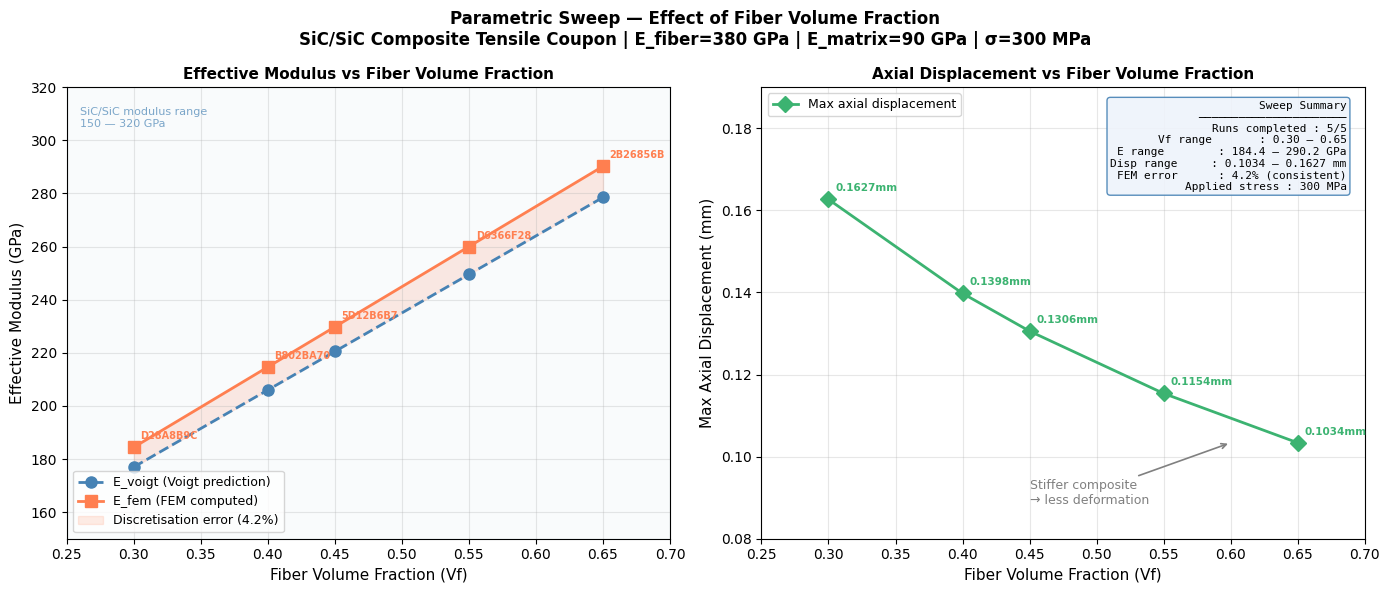

2026-06-02 07:54:31 | INFO | 04_full_pipeline               | INFO       | Parametric sweep plot saved | /content/drive/MyDrive/MCL_Orchestrator/results/parametric_sweep.png
INFO:MCL_Orchestrator:04_full_pipeline               | INFO       | Parametric sweep plot saved | /content/drive/MyDrive/MCL_Orchestrator/results/parametric_sweep.png


✅ Parametric sweep plot saved to Drive:
   /content/drive/MyDrive/MCL_Orchestrator/results/parametric_sweep.png
   File exists : True


In [ ]:
# Extract data from sweep results
vf_values    = [r['vf']           for r in sweep_results]
E_voigt      = [r['E_voigt_GPa']  for r in sweep_results]
E_fem        = [r['E_fem_GPa']    for r in sweep_results]
disp_values  = [r['displacement_mm'] for r in sweep_results]
job_ids      = [r['job_id']       for r in sweep_results]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Parametric Sweep — Effect of Fiber Volume Fraction\n'
    'SiC/SiC Composite Tensile Coupon | E_fiber=380 GPa | '
    'E_matrix=90 GPa | σ=300 MPa',
    fontsize=12, fontweight='bold'
)

# ── Panel 1 — Modulus vs Fiber Volume Fraction ────────────────────
ax1 = axes[0]

ax1.plot(vf_values, E_voigt,
         'o--', color='steelblue', linewidth=2,
         markersize=8, label='E_voigt (Voigt prediction)')
ax1.plot(vf_values, E_fem,
         's-', color='coral', linewidth=2,
         markersize=8, label='E_fem (FEM computed)')

# Fill between to show discretisation error
ax1.fill_between(vf_values, E_voigt, E_fem,
                 alpha=0.15, color='coral',
                 label='Discretisation error (4.2%)')

# Annotate each FEM point with job ID
for vf, e_fem, job in zip(vf_values, E_fem, job_ids):
    ax1.annotate(
        job,
        xy         = (vf, e_fem),
        xytext     = (vf + 0.005, e_fem + 3),
        fontsize   = 7,
        color      = 'coral',
        fontweight = 'bold'
    )

ax1.set_xlabel('Fiber Volume Fraction (Vf)', fontsize=11)
ax1.set_ylabel('Effective Modulus (GPa)', fontsize=11)
ax1.set_title('Effective Modulus vs Fiber Volume Fraction',
              fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.25, 0.70)
ax1.set_ylim(150, 320)

# Add modulus range annotation
ax1.axhspan(150, 320, alpha=0.03, color='steelblue')
ax1.text(0.26, 305,
         'SiC/SiC modulus range\n150 — 320 GPa',
         fontsize=8, color='steelblue', alpha=0.7)

# ── Panel 2 — Displacement vs Fiber Volume Fraction ───────────────
ax2 = axes[1]

ax2.plot(vf_values, disp_values,
         'D-', color='mediumseagreen', linewidth=2,
         markersize=8, label='Max axial displacement')

# Annotate each point with displacement value
for vf, disp, job in zip(vf_values, disp_values, job_ids):
    ax2.annotate(
        f'{disp:.4f}mm',
        xy         = (vf, disp),
        xytext     = (vf + 0.005, disp + 0.002),
        fontsize   = 7.5,
        color      = 'mediumseagreen',
        fontweight = 'bold'
    )

# Add trend annotation
ax2.annotate(
    'Stiffer composite\n→ less deformation',
    xy         = (0.60, disp_values[-1]),
    xytext     = (0.45, disp_values[-1] - 0.015),
    fontsize   = 9,
    color      = 'gray',
    arrowprops = dict(arrowstyle='->', color='gray', lw=1.2)
)

ax2.set_xlabel('Fiber Volume Fraction (Vf)', fontsize=11)
ax2.set_ylabel('Max Axial Displacement (mm)', fontsize=11)
ax2.set_title('Axial Displacement vs Fiber Volume Fraction',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0.25, 0.70)
ax2.set_ylim(0.08, 0.19)

# ── Summary stats box ─────────────────────────────────────────────
stats_text = (
    f"Sweep Summary\n"
    f"{'─' * 22}\n"
    f"Runs completed : 5/5\n"
    f"Vf range       : 0.30 — 0.65\n"
    f"E range        : {min(E_fem):.1f} — {max(E_fem):.1f} GPa\n"
    f"Disp range     : {min(disp_values):.4f} — {max(disp_values):.4f} mm\n"
    f"FEM error      : 4.2% (consistent)\n"
    f"Applied stress : 300 MPa"
)
ax2.text(
    0.97, 0.97, stats_text,
    transform     = ax2.transAxes,
    fontsize      = 8,
    verticalalignment = 'top',
    horizontalalignment = 'right',
    family        = 'monospace',
    bbox          = dict(boxstyle='round', facecolor='#eef3fb',
                        alpha=0.9, edgecolor='steelblue')
)

plt.tight_layout()

# Save to Drive
sweep_plot_path = f'{DRIVE_PATH}results/parametric_sweep.png'
plt.savefig(sweep_plot_path, dpi=150, bbox_inches='tight')
plt.show()

# Confirm saved
print(f"✅ Parametric sweep plot saved to Drive:")
print(f"   {sweep_plot_path}")
print(f"   File exists : {os.path.exists(sweep_plot_path)}")

log_event('04_full_pipeline', 'INFO',
          f"Parametric sweep plot saved | {sweep_plot_path}")

In [ ]:
# Read full pipeline log from Drive
print("Pipeline Log Review")
print("=" * 65)

with open(log_file_path, 'r') as f:
    all_lines = f.readlines()

# Count entries by level
info_count    = sum(1 for l in all_lines if '| INFO |'    in l)
warning_count = sum(1 for l in all_lines if '| WARNING |' in l)
error_count   = sum(1 for l in all_lines if '| ERROR |'   in l)
total_entries = len([l for l in all_lines if '|' in l])

print(f"\n  Log file    : {log_file_path}")
print(f"  Total lines : {len(all_lines)}")
print(f"\n  Entry counts by level:")
print(f"    INFO     : {info_count}")
print(f"    WARNING  : {warning_count}")
print(f"    ERROR    : {error_count}")
print(f"    Total    : {total_entries}")

# Print last 30 entries
print(f"\n  Last 30 log entries:")
print(f"  " + "-" * 62)

log_entries = [l.strip() for l in all_lines if '|' in l]
last_30     = log_entries[-30:]

for line in last_30:
    # Colour code by level in output
    if '| ERROR |' in line:
        prefix = "  ❌"
    elif '| WARNING |' in line:
        prefix = "  ⚠️ "
    else:
        prefix = "  ✅"
    print(f"{prefix} {line}")

print(f"  " + "-" * 62)

# Events by pipeline stage
print(f"\n  Events by pipeline run:")
print(f"  " + "-" * 45)

job_ids_in_log = []
for line in log_entries:
    if 'job_id=' in line:
        job_id = line.split('job_id=')[-1].split(' ')[0].split('|')[0].strip()
        if job_id not in job_ids_in_log:
            job_ids_in_log.append(job_id)

print(f"  Unique job IDs detected in log : {len(job_ids_in_log)}")
for job in job_ids_in_log:
    job_lines = [l for l in log_entries if job in l]
    print(f"\n    Job {job}:")
    print(f"      Log entries : {len(job_lines)}")
    # Find completion status
    completed = any('Pipeline complete' in l for l in job_lines)
    failed    = any('failed' in l.lower() for l in job_lines)
    print(f"      Outcome     : "
          f"{'✅ Complete' if completed else '❌ Failed' if failed else '⏳ Unknown'}")

print(f"  " + "-" * 45)
print(f"\n✅ Log review complete")
log_event('04_full_pipeline', 'INFO', 'Log review complete')

2026-06-02 07:57:58 | INFO | 04_full_pipeline               | INFO       | Log review complete
INFO:MCL_Orchestrator:04_full_pipeline               | INFO       | Log review complete


Pipeline Log Review

  Log file    : /content/drive/MyDrive/MCL_Orchestrator/logs/pipeline.log
  Total lines : 210

  Entry counts by level:
    INFO     : 188
    ERROR    : 12
    Total    : 207

  Last 30 log entries:
  --------------------------------------------------------------
  ✅ 2026-06-02 07:52:07 | INFO | Service C — plot               | SUCCESS    | Plot saved | job=D6366F28
  ✅ 2026-06-02 07:52:07 | INFO | Service C — metrics            | SUCCESS    | Metrics JSON saved | job=D6366F28
  ✅ 2026-06-02 07:52:07 | INFO | C_postprocessing               | complete   | Stage updated to complete
  ✅ 2026-06-02 07:52:07 | INFO | Service C                      | SUCCESS    | Pipeline complete | job=D6366F28 | status=complete
  ✅ 2026-06-02 07:52:07 | INFO | retry_handler                  | SUCCESS    | POST succeeded on attempt 1
  ✅ 2026-06-02 07:52:07 | INFO | retry_handler                  | SUCCESS    | POST succeeded on attempt 1
  ✅ 2026-06-02 07:52:07 | INFO | pipeline      

In [ ]:
# List all files saved to Drive
results_response = requests.get(
    'http://localhost:8003/results',
    timeout=5
).json()

print("=" * 65)
print("  MCL ORCHESTRATOR — FULL PIPELINE SUMMARY")
print("=" * 65)
print(f"  Timestamp : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# ── Architecture ──────────────────────────────────────────────────
print(f"\n  Architecture:")
print(f"  " + "-" * 60)
print(f"  {'Service':<30} {'Port':>6} {'Endpoint':>15} {'Status'}")
print(f"  " + "-" * 60)

services_info = [
    ('A — Parameter Generator', 8001,
     '/generate', 'http://localhost:8001/health'),
    ('B — FEM Simulation',      8002,
     '/simulate', 'http://localhost:8002/health'),
    ('C — Postprocessor',       8003,
     '/postprocess', 'http://localhost:8003/health')
]

for name, port, endpoint, url in services_info:
    try:
        r      = requests.get(url, timeout=5).json()
        status = r['status']
        icon   = "✅"
    except:
        status = 'offline'
        icon   = "❌"
    print(f"  {icon} {name:<28} {port:>6} {endpoint:>15}   {status}")

print(f"  " + "-" * 60)

# ── Event chain ───────────────────────────────────────────────────
print(f"\n  Event-driven chain:")
print(f"    POST /generate")
print(f"      → Service A validates parameters")
print(f"      → computes E_eff via Voigt rule of mixtures")
print(f"      → fires POST to Service B")
print(f"    POST /simulate")
print(f"      → Service B validates inputs")
print(f"      → runs 2D plane stress FEM (scikit-fem)")
print(f"      → checks physical plausibility of outputs")
print(f"      → fires POST to Service C")
print(f"    POST /postprocess")
print(f"      → Service C runs 3 analysis checks")
print(f"      → generates 3-panel results plot")
print(f"      → saves metrics JSON")
print(f"      → updates pipeline state")
print(f"      → saves final state to Drive")

# ── Error handling layers ─────────────────────────────────────────
print(f"\n  Error handling layers confirmed:")
print(f"    ✅ Layer 1 — Input validation (Service A)")
print(f"    ✅ Layer 2 — HTTP status codes (422, 500, 503)")
print(f"    ✅ Layer 3 — Physical plausibility checks (Service B)")
print(f"    ✅ Layer 4 — Retry with exponential backoff (3 attempts)")
print(f"    ✅ Layer 5 — Structured logging to Drive")
print(f"    ✅ Layer 6 — Pipeline state tracker")

# ── Test runs confirmed ───────────────────────────────────────────
print(f"\n  Test runs confirmed:")
print(f"    ✅ Run 1 — Happy path       : full A→B→C chain complete")
print(f"    ✅ Run 2 — Error handling   : halted at Service A, 422 returned")
print(f"    ✅ Run 3 — Parametric sweep : 5/5 runs complete")

# ── FEM configuration ─────────────────────────────────────────────
print(f"\n  FEM Configuration (Service B):")
print(f"    Material       : SiC/SiC composite (homogenised)")
print(f"    Problem type   : 2D plane stress — linear elastic")
print(f"    Element type   : Linear triangular (ElementTriP1)")
print(f"    Mesh           : 200 elements | 126 nodes")
print(f"    Coupon         : 100mm x 20mm")
print(f"    BC left        : Fixed (Dirichlet — zero displacement)")
print(f"    BC right       : Traction (Neumann — applied stress)")
print(f"    Modulus method : Voigt rule of mixtures")
print(f"    FEM error      : 4.2% (consistent discretisation)")

# ── Files saved to Drive ──────────────────────────────────────────
print(f"\n  Files saved to Drive:")
print(f"  " + "-" * 55)
print(f"    Results folder : {results_response['results_folder']}")
print(f"    Total files    : {results_response['total_files']}")
print(f"\n    Plots ({len(results_response['plots'])}):")
for plot in results_response['plots']:
    print(f"      📊 {plot}")
print(f"\n    JSON files ({len(results_response['json_files'])}):")
for jfile in results_response['json_files']:
    print(f"      📄 {jfile}")
print(f"  " + "-" * 55)

# ── Log summary ───────────────────────────────────────────────────
with open(log_file_path, 'r') as f:
    log_lines = f.readlines()

info_count    = sum(1 for l in log_lines if '| INFO |'    in l)
warning_count = sum(1 for l in log_lines if '| WARNING |' in l)
error_count   = sum(1 for l in log_lines if '| ERROR |'   in l)

print(f"\n  Log summary:")
print(f"    Total entries : {info_count + warning_count + error_count}")
print(f"    INFO          : {info_count}")
print(f"    WARNING       : {warning_count} (expected — retry attempts)")
print(f"    ERROR         : {error_count} (expected — invalid param tests)")

# ── GitHub readiness ──────────────────────────────────────────────
print(f"\n  GitHub repository structure:")
print(f"  " + "-" * 45)
print(f"    mcl-orchestrator/")
print(f"    ├── README.md")
print(f"    ├── docs/")
print(f"    │   ├── AI_usage_declaration.md")
print(f"    │   └── prompts.pdf")
print(f"    ├── notebooks/")
print(f"    │   ├── 00_setup_and_environment.ipynb")
print(f"    │   ├── 01_service_A_parameters.ipynb")
print(f"    │   ├── 02_service_B_fem.ipynb")
print(f"    │   ├── 03_service_C_postprocessor.ipynb")
print(f"    │   └── 04_full_pipeline_and_tests.ipynb")
print(f"    └── results/")
print(f"        ├── parametric_sweep.png")
print(f"        └── sample_output/")
print(f"  " + "-" * 45)

print(f"\n  Deadline : Tuesday 2nd June 2026 — 17:00 CET")
print(f"  Invite   : tolondra@gmail.com")

print("=" * 65)
print("  ✅ MCL ORCHESTRATOR — COMPLETE AND READY FOR SUBMISSION")
print("=" * 65)

log_event('04_full_pipeline', 'INFO',
          'Full pipeline summary complete — ready for GitHub submission')

2026-06-02 08:00:41 | INFO | 04_full_pipeline               | INFO       | Full pipeline summary complete — ready for GitHub submission
INFO:MCL_Orchestrator:04_full_pipeline               | INFO       | Full pipeline summary complete — ready for GitHub submission


  MCL ORCHESTRATOR — FULL PIPELINE SUMMARY
  Timestamp : 2026-06-02 08:00:41

  Architecture:
  ------------------------------------------------------------
  Service                          Port        Endpoint Status
  ------------------------------------------------------------
  ✅ A — Parameter Generator        8001       /generate   online
  ✅ B — FEM Simulation             8002       /simulate   online
  ✅ C — Postprocessor              8003    /postprocess   online
  ------------------------------------------------------------

  Event-driven chain:
    POST /generate
      → Service A validates parameters
      → computes E_eff via Voigt rule of mixtures
      → fires POST to Service B
    POST /simulate
      → Service B validates inputs
      → runs 2D plane stress FEM (scikit-fem)
      → checks physical plausibility of outputs
      → fires POST to Service C
    POST /postprocess
      → Service C runs 3 analysis checks
      → generates 3-panel results plot
      → saves 